In [ ]:
!pip install librosa

In [ ]:
import numpy as np
import os
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# dataset/
#    rock/
#    pop/
#    jazz/
#    classical/
#    hiphop/
#    electronic/
# !wget https://web.archive.org/web/20220328223413/ftp://opihi.cs.uvic.ca/sound/genres.tar.gz
# !tar -xzf genres.tar.gz

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # memoria dinámica para no reservar toda la VRAM de golpe
    tf.config.experimental.set_memory_growth(gpus[0], enable=True)
    print(f"GPU detectada: {gpus[0].name}")
else:
    print("No se detectó GPU, usando CPU")

DATASET_PATH = "/content/genres"
SAMPLE_RATE = 22050
DURATION = 30
SAMPLES_PER_TRACK = SAMPLE_RATE * DURATION
N_MFCC = 40
MAX_LEN = 1300
VALID_EXTENSIONS = (".wav", ".au", ".mp3")

print("--->", DATASET_PATH)
print("--->", os.listdir(DATASET_PATH))

GPU detectada: /physical_device:GPU:0
---> /content/genres
---> ['metal', 'bextract_single.mf', 'pop', 're.mf', 'di.mf', 'classical', 'hiphop', 'bl.mf', 'jazz', 'reggae', 'cl.mf', 'rock', 'blues', 'co.mf', 'me.mf', 'disco', 'country', 'ja.mf', 'hi.mf', 'ro.mf', 'po.mf', 'input.mf']


In [ ]:
# ─── Extracción de features

def extract_features_from_signal(signal, sr, n_mfcc=N_MFCC):
    """Extrae MFCCs, chroma, spectral contrast, tonnetz y ZCR de una señal."""
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)                        # (n_mfcc, T)
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr)                               # (12, T)
    spectral_contrast = librosa.feature.spectral_contrast(y=signal, sr=sr)              # (7, T)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(signal), sr=sr)        # (6, T)
    zcr = librosa.feature.zero_crossing_rate(signal)                                    # (1, T)

    features = np.vstack([mfcc, chroma, spectral_contrast, tonnetz, zcr])  # (66, T)
    return features.T  # (T, 66)


def normalize_signal(signal):
    """Fuerza la señal a SAMPLES_PER_TRACK frames."""
    if len(signal) >= SAMPLES_PER_TRACK:
        return signal[:SAMPLES_PER_TRACK]
    return np.pad(signal, (0, SAMPLES_PER_TRACK - len(signal)))



In [ ]:
# ─── Data augmentation

def augment_signal(signal, sr):
    """Aplica transformaciones aleatorias para aumentar el dataset."""
    choice = np.random.randint(0, 3)
    if choice == 0:
        # Pitch shift ±2 semitonos
        steps = np.random.uniform(-2, 2)
        signal = librosa.effects.pitch_shift(signal, sr=sr, n_steps=steps)
    elif choice == 1:
        # Ruido gaussiano leve
        signal = signal + 0.005 * np.random.randn(len(signal))
    else:
        # Time stretch entre 0.9x y 1.1x
        rate = np.random.uniform(0.9, 1.1)
        signal = librosa.effects.time_stretch(signal, rate=rate)
    return normalize_signal(signal)


In [ ]:
# ─── Carga del dataset
def load_dataset(dataset_path, augment=True):
    X, y = [], []

    for genre in sorted(os.listdir(dataset_path)):
        genre_path = os.path.join(dataset_path, genre)
        if not os.path.isdir(genre_path):
            continue

        print(f"Procesando: {genre}")

        for file in os.listdir(genre_path):
            if not file.lower().endswith(VALID_EXTENSIONS):
                continue

            file_path = os.path.join(genre_path, file)
            try:
                signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
                signal = normalize_signal(signal)

                # muestra original
                X.append(extract_features_from_signal(signal, sr))
                y.append(genre)

                # muestra aumentada
                if augment:
                    aug_signal = augment_signal(signal, sr)
                    X.append(extract_features_from_signal(aug_signal, sr))
                    y.append(genre)

            except Exception as e:
                print(f"  Error en {file_path}: {e}")

    return np.array(X), np.array(y)


In [ ]:
# ─── Pipeline principal

X, y = load_dataset(DATASET_PATH, augment=True)
print(f"Total muestras (con augmentation): {len(X)}")
print(f"Shape de una muestra: {X[0].shape}")

# Padding/truncating a MAX_LEN frames
X_padded = pad_sequences(X, maxlen=MAX_LEN, padding='post', truncating='post', dtype='float32')

# Encoding de etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)
n_classes = y_categorical.shape[1]
n_features = X_padded.shape[2]

print(f"Clases: {le.classes_}")
print(f"Shape final X: {X_padded.shape}")

# División estratificada para balancear clases
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Procesando: blues
Procesando: classical
Procesando: country
Procesando: disco
Procesando: hiphop
Procesando: jazz
Procesando: metal
Procesando: pop
Procesando: reggae
Procesando: rock
Total muestras (con augmentation): 2000
Shape de una muestra: (1292, 66)
Clases: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
Shape final X: (2000, 1300, 66)
Train: (1600, 1300, 66) | Test: (400, 1300, 66)


In [ ]:
model = Sequential([
    # Eliminamos L2 para permitir que el modelo aprenda patrones más complejos
    Bidirectional(LSTM(256, return_sequences=True), input_shape=(MAX_LEN, n_features)),
    Dropout(0.3),
    Bidirectional(LSTM(128)),
    Dropout(0.3),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])

# Adam con una tasa de aprendizaje estándar para mayor dinamismo inicial
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_10                │ (None, 1300, 512)      │       661,504 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 1300, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 256)            │       656,384 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,584,394 (6.04 MB)

 Trainable params: 1,583,882 (6.04 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
callbacks = [
    # Restauramos una paciencia equilibrada para val_accuracy
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
# ─── Entrenamiento

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=32,
    callbacks=callbacks
)

Epoch 1/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 290ms/step - accuracy: 0.2556 - loss: 2.1027 - val_accuracy: 0.3775 - val_loss: 1.8852 - learning_rate: 0.0010
Epoch 2/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 282ms/step - accuracy: 0.4081 - loss: 1.6462 - val_accuracy: 0.4475 - val_loss: 1.7224 - learning_rate: 0.0010
Epoch 3/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 279ms/step - accuracy: 0.5263 - loss: 1.3622 - val_accuracy: 0.5450 - val_loss: 1.4483 - learning_rate: 0.0010
Epoch 4/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.5750 - loss: 1.1956 - val_accuracy: 0.5625 - val_loss: 1.3222 - learning_rate: 0.0010
Epoch 5/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 271ms/step - accuracy: 0.6538 - loss: 0.9854 - val_accuracy: 0.5800 - val_loss: 1.2180 - learning_rate: 0.0010
Epoch 6/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 297ms/step - accuracy: 0.6844 - loss: 0.9069 - val_accuracy: 0.5575 - val_loss: 1.4974 - learning_rate: 0.0010
Epoch 7/150
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 272ms/step - accuracy: 0.7362 - l

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step


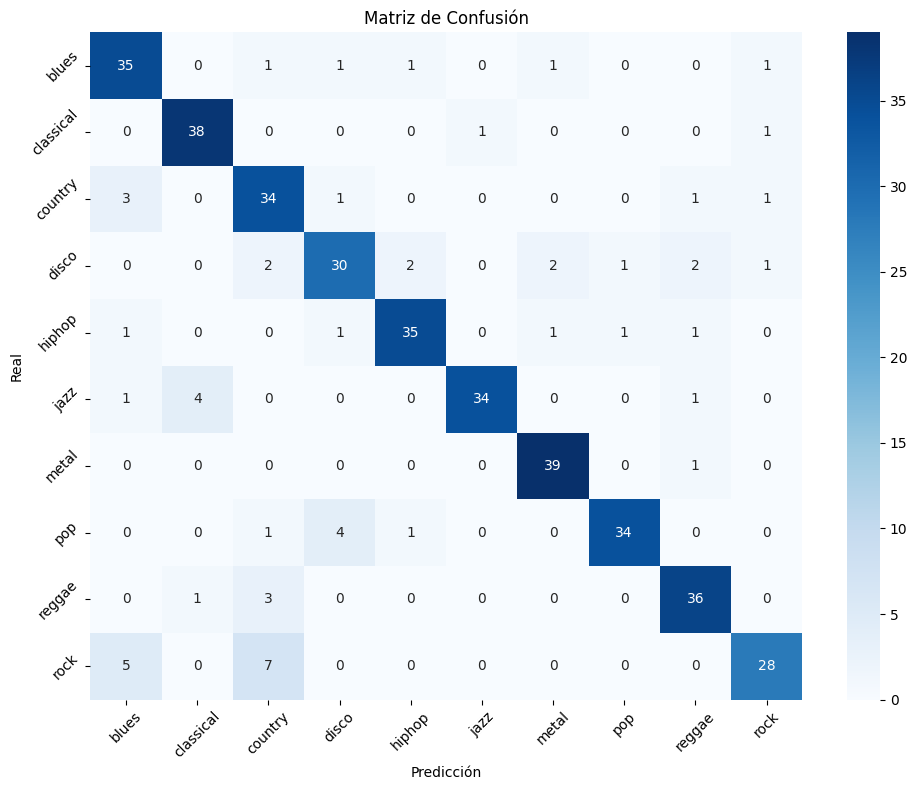

              precision    recall  f1-score   support

       blues       0.78      0.88      0.82        40
   classical       0.88      0.95      0.92        40
     country       0.71      0.85      0.77        40
       disco       0.81      0.75      0.78        40
      hiphop       0.90      0.88      0.89        40
        jazz       0.97      0.85      0.91        40
       metal       0.91      0.97      0.94        40
         pop       0.94      0.85      0.89        40
      reggae       0.86      0.90      0.88        40
        rock       0.88      0.70      0.78        40

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



In [ ]:
# ─── Matriz de confusión
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predicciones
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=le.classes_))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.8575 - loss: 0.8366

Accuracy en test: 0.8575 (85.75%)


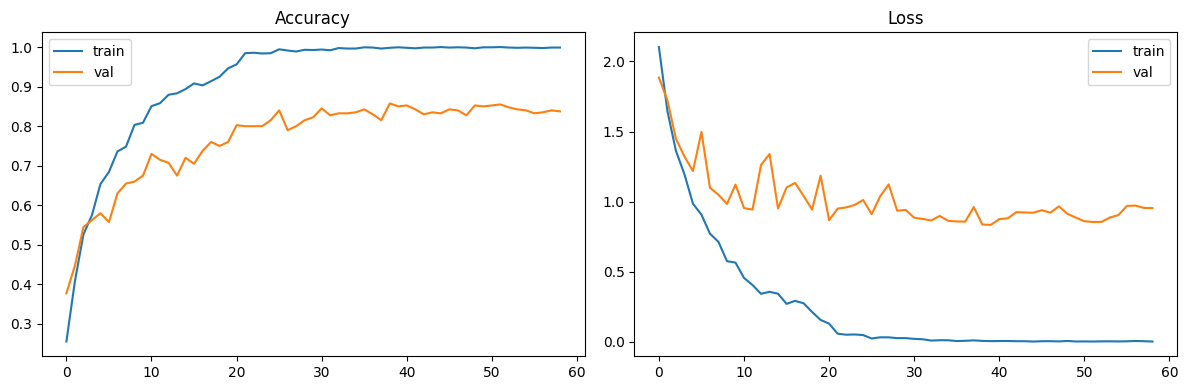

In [ ]:
# ─── Evaluación
loss, acc = model.evaluate(X_test, y_test)
print(f"\nAccuracy en test: {acc:.4f} ({acc*100:.2f}%)")

# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Accuracy')
ax1.legend()
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.set_title('Loss')
ax2.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ─── Predicción

def predict_genre(file_path, model, label_encoder):
    """Predice el género de un archivo de audio."""
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    signal = normalize_signal(signal)
    features = extract_features_from_signal(signal, sr)
    features_padded = pad_sequences([features], maxlen=MAX_LEN, padding='post',
                                     truncating='post', dtype='float32')
    prediction = model.predict(features_padded, verbose=0)
    genre = label_encoder.inverse_transform([np.argmax(prediction)])[0]
    confidence = np.max(prediction)
    print(f"Género predicho: {genre} (confianza: {confidence:.2%})")
    return genre


In [ ]:
def predict_genre_with_probs(file_path, model, label_encoder):
    """Predice el género y muestra la distribución de probabilidades."""
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)
    signal = normalize_signal(signal)
    features = extract_features_from_signal(signal, sr)
    features_padded = pad_sequences([features], maxlen=MAX_LEN, padding='post',
                                     truncating='post', dtype='float32')

    prediction_probs = model.predict(features_padded, verbose=0)[0]
    genres = label_encoder.classes_

    # Graficar
    plt.figure(figsize=(10, 5))
    plt.bar(genres, prediction_probs, color='skyblue')
    plt.title("Distribución de Probabilidades por Género")
    plt.ylabel("Probabilidad")
    plt.xticks(rotation=45)
    plt.show()

    predicted_idx = np.argmax(prediction_probs)
    print(f"Género predicho: {genres[predicted_idx]} (confianza: {prediction_probs[predicted_idx]:.2%})")

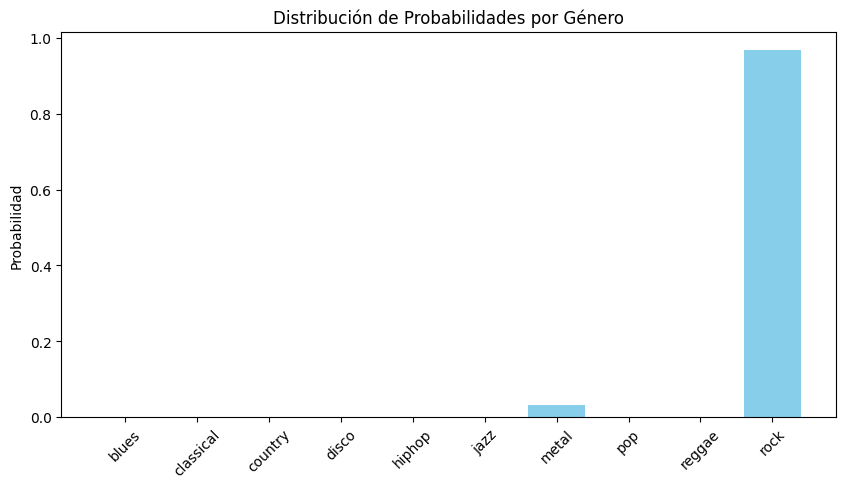

Género predicho: rock (confianza: 96.73%)


In [ ]:
# Probar con el nuevo análisis visual
predict_genre_with_probs("/content/test.wav", model, le)

In [ ]:
# Ejemplo de uso:
predict_genre("/content/test.wav", model, le)


Género predicho: rock (confianza: 96.73%)


np.str_('rock')

In [ ]:
model.save("music_genre_classifier.h5")
print("Modelo guardado en music_genre_classifier.h5")

Modelo guardado en music_genre_classifier.h5
